# Set Up

## A. Library

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
%pip install transformers

Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.patches as mpatches


d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## B.Model

In [3]:
# =========================================================
# 1. SETUP LIBRARY & DEVICE
# =========================================================

print("-" * 50)
# Deteksi perangkat (Sangat disarankan outputnya CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")

if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Peringatan: GPU tidak terdeteksi, proses ekstraksi akan berjalan lambat di CPU.")
print("-" * 50)

--------------------------------------------------
Device yang digunakan: cuda
Nama GPU: NVIDIA GeForce RTX 3060 Laptop GPU
--------------------------------------------------


In [4]:
# =========================================================
# 2. LOAD INDOBERT & XLM-R (LAYER-WISE MODE)
# =========================================================

# --- A. INDOBERT (Model Utama) ---
print("Loading IndoBERT (indolem/indobert-base-uncased)...")
indobert_name = "indolem/indobert-base-uncased"
tokenizer_indobert = AutoTokenizer.from_pretrained(indobert_name)
model_indobert = AutoModel.from_pretrained(indobert_name, output_hidden_states=True).to(device)
model_indobert.eval() # Set ke mode evaluasi

# --- B. XLM-R (Model Pembanding) ---
print("Loading XLM-R (xlm-roberta-base)...")
xlmr_name = "xlm-roberta-base"
tokenizer_xlmr = AutoTokenizer.from_pretrained(xlmr_name)
model_xlmr = AutoModel.from_pretrained(xlmr_name, output_hidden_states=True).to(device)
model_xlmr.eval() # Set ke mode evaluasi

print("-" * 50)
print("✅ Kedua model berhasil di-load dengan output_hidden_states=True!")

Loading IndoBERT (indolem/indobert-base-uncased)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17560.47it/s]
BertModel LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading XLM-R (xlm-roberta-base)...


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "D:\UNIVERSITASSEBELASMARET\Anaconda\Lib\threading.py", line 1038, in _bootstrap_inner
    self.run()
  File "D:\UNIVERSITASSEBELASMARET\Anaconda\Lib\threading.py", line 975, in run
    self._target(*self._args, **self._kwargs)
  File "d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\transformers\safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\transformers\safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Pro

--------------------------------------------------
✅ Kedua model berhasil di-load dengan output_hidden_states=True!


In [5]:
# =========================================================
# STEP 3: FUNGSI PENYELARASAN TOKEN (SUB-WORD ALIGNMENT)
# =========================================================

def extract_word_representations(model, tokenizer, sentence, device):
    words = str(sentence).split()
    input_ids = [tokenizer.cls_token_id]
    first_subword_indices = [] 
    
    for word in words:
        sub_words = tokenizer.encode(word, add_special_tokens=False)
        if not sub_words: 
            continue
        # Simpan indeks posisi sub-word pertama
        first_subword_indices.append(len(input_ids))
        input_ids.extend(sub_words)
        
    input_ids.append(tokenizer.sep_token_id)
    input_tensor = torch.tensor([input_ids]).to(device)
    
    # Ekstraksi tanpa mengubah bobot (frozen)
    with torch.no_grad():
        outputs = model(input_tensor)
        hidden_states = outputs.hidden_states # Tuple isi 13 tensor
        
    sentence_vectors = []
    for idx in first_subword_indices:
        word_layer_vectors = []
        for layer_idx in range(13):
            # Ambil vektor dan pindahkan ke CPU (numpy) sementara untuk menghemat VRAM GPU
            vec = hidden_states[layer_idx][0, idx, :].cpu().numpy()
            word_layer_vectors.append(vec)
        sentence_vectors.append(word_layer_vectors)
        
    return words, sentence_vectors

print("✅ STEP 3: Fungsi ekstraksi berhasil dibuat!")

✅ STEP 3: Fungsi ekstraksi berhasil dibuat!


In [6]:
# =========================================================
# STEP 4: LOAD DATASET & PREPROCESSING LABEL
# =========================================================

# 1. Load Data Train
train_path = "../data/processed/POS_Tagging/indolem_train_pos.csv"
df_train = pd.read_csv(train_path)

# 2. Preprocessing Data (Membangun ID Kalimat & Encoding Label)
# Membuat penanda kalimat secara otomatis berdasarkan baris kosong (NaN)
if 'sent_id' not in df_train.columns:
    df_train['sent_id'] = df_train['token'].isnull().cumsum()
    df_train = df_train.dropna(subset=['token']).reset_index(drop=True)

# 3. Mengubah label teks ('NOUN', 'VERB') menjadi angka (0, 1, 2)
label_encoder = LabelEncoder()
df_train['label_id'] = label_encoder.fit_transform(df_train['pos_tag'].astype(str))
NUM_CLASSES = len(label_encoder.classes_)

print("✅ STEP 4 Selesai!")
print(f"Total baris data (token): {len(df_train)}")
print(f"Jumlah kelas POS Tag   : {NUM_CLASSES}")
print(f"Daftar Kelas           : {label_encoder.classes_}")
display(df_train.head()) # Menampilkan cuplikan data yang sudah dirapikan

✅ STEP 4 Selesai!
Total baris data (token): 942214
Jumlah kelas POS Tag   : 23
Daftar Kelas           : ['CC' 'CD' 'DT' 'FW' 'IN' 'JJ' 'MD' 'NEG' 'NN' 'NND' 'NNP' 'OD' 'PR' 'PRP'
 'RB' 'RP' 'SC' 'SYM' 'UH' 'VB' 'WH' 'X' 'Z']


,sent_id,token_id,token,pos_tag,label_id
0,train_1,1,Pemerintah,NN,8
1,train_1,2,bahkan,RB,14
2,train_1,3,telah,MD,6
3,train_1,4,mencanangkan,VB,19
4,train_1,5,dana,NN,8


In [7]:
# =========================================================
# STEP 5: EKSTRAKSI FITUR MASSAL
# =========================================================

# 1. Tentukan folder penyimpanan spesifik untuk tugas POS Tagging
SAVE_DIR = "pos_tagging/features_memmap"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Folder penyimpanan siap di: {SAVE_DIR}")

def extract_dataset_memmap(df, model, tokenizer, device, prefix="train"):
    total_tokens_est = len(df)
    X_layers = {}
    
    # Alokasi file kosong di hard disk untuk 13 layer
    print(f"Menyiapkan file matriks {prefix} di hard disk...")
    for i in range(13):
        file_path = os.path.join(SAVE_DIR, f"{prefix}_layer_{i}.dat")
        X_layers[i] = np.memmap(file_path, dtype='float32', mode='w+', shape=(total_tokens_est, 768))
        
    y_labels = []
    grouped = df.groupby('sent_id')
    current_idx = 0
    
    for _, group in tqdm(grouped, desc=f"Mengekstrak Fitur ({prefix})"):
        tokens = group['token'].astype(str).tolist()
        labels = group['label_id'].tolist()
        kalimat = " ".join(tokens)
        
        # Panggil fungsi ekstraksi dari Step 3
        _, extracted_vectors = extract_word_representations(model, tokenizer, kalimat, device)
        
        valid_len = min(len(labels), len(extracted_vectors))
        if valid_len == 0:
            continue
            
        # Simpan vektor langsung ke file memmap di hard disk
        for i in range(valid_len):
            y_labels.append(labels[i])
            for layer_idx in range(13):
                X_layers[layer_idx][current_idx + i] = extracted_vectors[i][layer_idx]
                
        current_idx += valid_len
        
        # Amankan data ke disk setiap 10.000 kata agar memori RAM tidak bengkak
        if current_idx % 10000 == 0:
            for layer_idx in range(13):
                X_layers[layer_idx].flush()
                
    # Pastikan sisa data terakhir tersimpan permanen di disk
    for layer_idx in range(13):
        X_layers[layer_idx].flush()
        
    y_labels = np.array(y_labels)
    
    return X_layers, y_labels, current_idx

# 2. Eksekusi Ekstraksi Hemat RAM
print("\nMengekstrak fitur Train dengan IndoBERT...")
X_train_indo_mmap, y_train_indo, total_valid = extract_dataset_memmap(
    df=df_train, 
    model=model_indobert, 
    tokenizer=tokenizer_indobert, 
    device=device, 
    prefix="train_indobert"
)

print("-" * 50)
print(f"✅ STEP 5 Selesai (Versi Hemat RAM)!")
print(f"Total token berhasil diekstrak : {total_valid} kata")
print(f"File matriks tersimpan aman di folder '{SAVE_DIR}/'")

Folder penyimpanan siap di: pos_tagging/features_memmap

Mengekstrak fitur Train dengan IndoBERT...
Menyiapkan file matriks train_indobert di hard disk...


Mengekstrak Fitur (train_indobert): 100%|██████████| 36110/36110 [24:36<00:00, 24.46it/s]  


--------------------------------------------------
✅ STEP 5 Selesai (Versi Hemat RAM)!
Total token berhasil diekstrak : 942214 kata
File matriks tersimpan aman di folder 'pos_tagging/features_memmap/'


In [8]:
# =========================================================
# STEP 6: ARSITEKTUR SIMPLE LINEAR PROBE
# =========================================================
class SimpleLinearProbe(nn.Module):
    def __init__(self, hidden_size, num_classes):
        super(SimpleLinearProbe, self).__init__()
        # Murni satu lapisan linear tanpa hidden layer tambahan
        # dan tanpa fungsi aktivasi non-linear.
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        return self.classifier(x)

print("✅ STEP 6: Arsitektur SimpleLinearProbe berhasil didefinisikan!")

✅ STEP 6: Arsitektur SimpleLinearProbe berhasil didefinisikan!


In [ ]:
# =========================================================
# STEP 7: PERSIAPAN DATALOADER
# =========================================================

# Hyperparameter
BATCH_SIZE = 128 

# 1. Buat Custom Dataset untuk membaca file memmap sedikit demi sedikit
class MemmapDataset(Dataset):
    def __init__(self, X_memmap, y_array):
        self.X = X_memmap
        self.y = y_array
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        x_tensor = torch.tensor(self.X[idx], dtype=torch.float32)
        y_tensor = torch.tensor(self.y[idx], dtype=torch.long)
        return x_tensor, y_tensor

train_dataloaders = {}
print(f"Mempersiapkan DataLoader Lazy-Loading untuk 13 Layer (Batch Size: {BATCH_SIZE})...")

# 2. Bungkus array memmap masing-masing layer ke dalam DataLoader
for layer_idx in range(13):
    dataset = MemmapDataset(X_train_indo_mmap[layer_idx], y_train_indo)
    
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    train_dataloaders[layer_idx] = loader

print("✅ STEP 7 Selesai! DataLoader berhasil dibuat tanpa membebani RAM!")

Mempersiapkan DataLoader Lazy-Loading untuk 13 Layer (Batch Size: 128)...
✅ STEP 7 Selesai! DataLoader berhasil dibuat tanpa membebani RAM!


In [12]:
# =========================================================
# STEP 8: PELATIHAN LINEAR PROBE UNTUK SETIAP LAYER
# =========================================================

# Hiperparameter Pelatihan
EPOCHS = 10
LEARNING_RATE = 1e-3

# Dictionary untuk menyimpan model classifier yang sudah pintar untuk setiap layer
trained_probes = {}

print("Memulai Pelatihan Classifier per Layer...")

for layer_idx in range(13):
    print(f"\n--- Training Probe Layer {layer_idx} ---")
    
    # 1. Inisialisasi model probe baru khusus untuk layer ini
    probe = SimpleLinearProbe(hidden_size=768, num_classes=NUM_CLASSES).to(device)
    
    # 2. Definisikan Fungsi Kerugian (Loss) dan Pengoptimal (Optimizer)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(probe.parameters(), lr=LEARNING_RATE)
    
    # 3. Aktifkan Mode Training
    probe.train()
    
    for epoch in range(EPOCHS):
        total_loss = 0
        correct = 0
        total_samples = 0
        
        # --- TAMBAHAN PROGRESS BAR ---
        # leave=False agar bar-nya hilang setelah selesai dan digantikan oleh teks rapi
        batch_iterator = tqdm(train_dataloaders[layer_idx], desc=f"Epoch [{epoch+1:>2}/{EPOCHS}]", leave=False)
        
        # Ambil data sedikit demi sedikit (batching) dari DataLoader
        for batch_X, batch_y in batch_iterator:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Reset gradien
            optimizer.zero_grad()
            
            # Forward pass: prediksi kelas POS Tag
            outputs = probe(batch_X)
            
            # Hitung seberapa meleset prediksinya
            loss = criterion(outputs, batch_y)
            
            # Backward pass: koreksi bobot layer linear
            loss.backward()
            optimizer.step()
            
            # Kalkulasi akurasi training
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            # Update angka akurasi & loss di ujung progress bar secara real-time
            batch_iterator.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100 * correct / total_samples:.2f}%"
            })
            
        avg_loss = total_loss / len(train_dataloaders[layer_idx])
        acc = 100 * correct / total_samples
        
        # Tampilkan progress berupa teks permanen setelah loading epoch selesai
        print(f"Epoch [{epoch+1:>2}/{EPOCHS}] Selesai | Avg Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")
            
    # Simpan model yang sudah selesai dilatih ke dalam dictionary
    trained_probes[layer_idx] = probe

print("\n✅ STEP 8 Selesai! Seluruh (13) Linear Probe berhasil dilatih.")

Memulai Pelatihan Classifier per Layer...

--- Training Probe Layer 0 ---


Epoch [ 1/10] Selesai | Avg Loss: 0.2244 | Train Acc: 93.02%


Epoch [ 2/10] Selesai | Avg Loss: 0.1913 | Train Acc: 93.60%


Epoch [ 3/10] Selesai | Avg Loss: 0.1884 | Train Acc: 93.67%


Epoch [ 4/10] Selesai | Avg Loss: 0.1869 | Train Acc: 93.69%


...

Epoch [ 6/10] Selesai | Avg Loss: 0.1607 | Train Acc: 94.72%


Epoch [ 7/10] Selesai | Avg Loss: 0.1596 | Train Acc: 94.75%


Epoch [ 8/10] Selesai | Avg Loss: 0.1589 | Train Acc: 94.76%


Epoch [ 9/10] Selesai | Avg Loss: 0.1584 | Train Acc: 94.78%


Epoch [10/10] Selesai | Avg Loss: 0.1581 | Train Acc: 94.80%

✅ STEP 8 Selesai! Seluruh (13) Linear Probe berhasil dilatih.


In [14]:
# =========================================================
# STEP 9: LOAD & EKSTRAKSI FITUR DATA TEST
# =========================================================

# 1. Load Data Test
test_path = "../data/processed/POS_Tagging/indolem_test_pos.csv"
df_test = pd.read_csv(test_path)

# 2. Preprocessing Data Test
if 'sent_id' not in df_test.columns:
    df_test['sent_id'] = df_test['token'].isnull().cumsum()
    df_test = df_test.dropna(subset=['token']).reset_index(drop=True)

# PENTING: Gunakan .transform() saja, BUKAN .fit_transform()
# Agar angka label test selaras dengan data train
df_test['label_id'] = label_encoder.transform(df_test['pos_tag'].astype(str))

# 3. Ekstraksi Fitur Test menggunakan fungsi memmap (Hemat RAM)
print("Mengekstrak fitur TEST dengan IndoBERT ke Hard Disk...")
X_test_indo_mmap, y_test_indo, total_valid_test = extract_dataset_memmap(
    df=df_test, 
    model=model_indobert, 
    tokenizer=tokenizer_indobert, 
    device=device, 
    prefix="test_indobert"  # <-- Penanda agar file test terpisah dari file train
)

print("-" * 50)
print(f"✅ STEP 9 Selesai")
print(f"Total token uji berhasil diekstrak : {total_valid_test} kata")
print(f"File matriks uji tersimpan aman di folder 'pos_tagging/features_memmap/'")

Mengekstrak fitur TEST dengan IndoBERT ke Hard Disk...
Menyiapkan file matriks test_indobert di hard disk...


Mengekstrak Fitur (test_indobert): 100%|██████████| 10030/10030 [06:29<00:00, 25.76it/s]


--------------------------------------------------
✅ STEP 9 Selesai
Total token uji berhasil diekstrak : 261872 kata
File matriks uji tersimpan aman di folder 'pos_tagging/features_memmap/'


In [16]:
# =========================================================
# STEP 10: EVALUASI PERFORMA PROBE DI DATA TEST
# =========================================================

print("Mulai mengevaluasi performa di data Test...")
eval_results = []

for layer_idx in range(13):
    # Ambil model probe yang sudah dilatih untuk layer ini
    probe = trained_probes[layer_idx]
    probe.eval() # Kunci ke mode evaluasi
    
    # Karena data test biasanya muat di memori GPU sekaligus (lebih kecil dari data train), 
    # kita bisa menghitungnya langsung tanpa DataLoader.
    # PENTING: Kita panggil X_test_indo_mmap dari Step 9
    X_test_tensor = torch.tensor(X_test_indo_mmap[layer_idx], dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test_indo, dtype=torch.long).to(device)
    
    with torch.no_grad():
        # Prediksi label
        outputs = probe(X_test_tensor)
        _, predictions = torch.max(outputs, 1)
        
        # Pindahkan kembali ke CPU untuk dihitung oleh Scikit-Learn
        preds_cpu = predictions.cpu().numpy()
        trues_cpu = y_test_tensor.cpu().numpy()
        
        # Hitung metrik
        acc = accuracy_score(trues_cpu, preds_cpu)
        f1 = f1_score(trues_cpu, preds_cpu, average='weighted')
        
        eval_results.append({
            'Model': 'IndoBERT',
            'Layer': layer_idx,
            'Accuracy': acc * 100,
            'F1_Score': f1 * 100
        })
        
    print(f"Layer {layer_idx:>2} -> Akurasi: {acc*100:.2f}% | F1-Score: {f1*100:.2f}%")

# Simpan hasil dalam DataFrame agar mudah di-plot
df_results_indo = pd.DataFrame(eval_results)

print("\n✅ STEP 10 Selesai! Hasil evaluasi IndoBERT berhasil direkam.")

Mulai mengevaluasi performa di data Test...
Layer  0 -> Akurasi: 93.07% | F1-Score: 92.99%
Layer  1 -> Akurasi: 95.15% | F1-Score: 95.13%
Layer  2 -> Akurasi: 96.45% | F1-Score: 96.44%
Layer  3 -> Akurasi: 96.57% | F1-Score: 96.55%
Layer  4 -> Akurasi: 96.79% | F1-Score: 96.78%
Layer  5 -> Akurasi: 96.78% | F1-Score: 96.77%
Layer  6 -> Akurasi: 96.80% | F1-Score: 96.78%
Layer  7 -> Akurasi: 96.63% | F1-Score: 96.62%
Layer  8 -> Akurasi: 96.35% | F1-Score: 96.33%
Layer  9 -> Akurasi: 96.06% | F1-Score: 96.04%
Layer 10 -> Akurasi: 95.78% | F1-Score: 95.79%
Layer 11 -> Akurasi: 95.52% | F1-Score: 95.50%
Layer 12 -> Akurasi: 94.83% | F1-Score: 94.82%

✅ STEP 10 Selesai! Hasil evaluasi IndoBERT berhasil direkam.


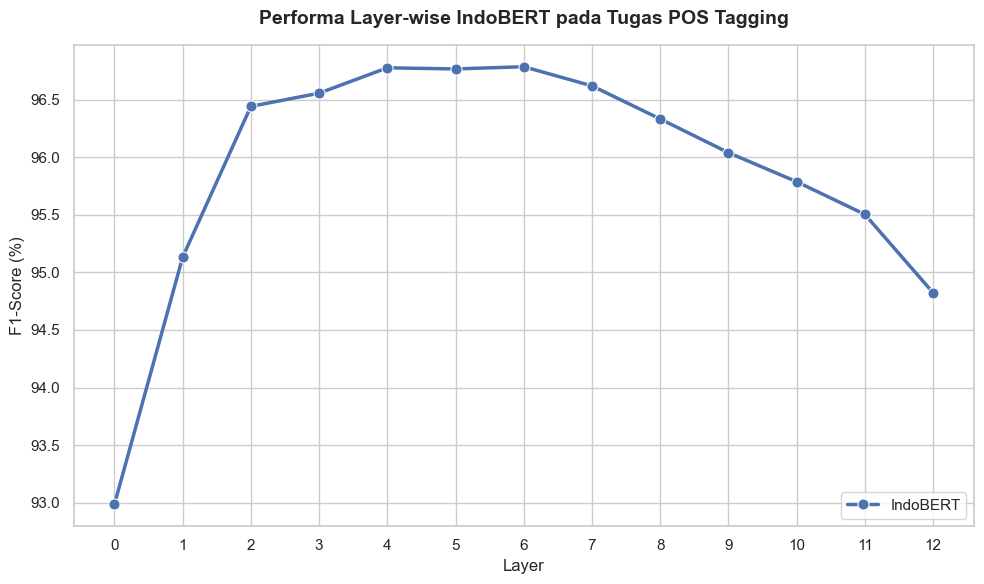

✅ STEP 11 Selesai! Grafik berhasil dibuat dan disimpan sebagai 'indobert_pos_tagging_layerwise.png'.


In [30]:
# =========================================================
# STEP 11: VISUALISASI HASIL EVALUASI LAYER-WISE
# =========================================================

# Set gaya grafik agar terlihat rapi dan akademis (cocok untuk skripsi)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Membuat grafik garis (Line Plot) untuk F1-Score
sns.lineplot(
    data=df_results_indo, 
    x='Layer', 
    y='F1_Score', 
    marker='o', 
    linewidth=2.5, 
    markersize=8,
    color='b',
    label='IndoBERT'
)

# Kustomisasi Sumbu dan Judul
plt.title('Performa Layer-wise IndoBERT pada Tugas POS Tagging', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Layer', fontsize=12)
plt.ylabel('F1-Score (%)', fontsize=12)

# Mengatur agar sumbu X menampilkan angka genap dari 0 sampai 12
plt.xticks(range(0, 13))

# (Opsional) Membatasi sumbu Y agar perbedaan performa lebih terlihat jelas
# plt.ylim(50, 100) # Aktifkan jika jarak angkanya terlalu berdekatan

plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

# Simpan grafik sebagai gambar untuk draf skripsi
plt.savefig('indobert_pos_tagging_layerwise.png', dpi=300)

# Tampilkan grafik
plt.show()

print("✅ STEP 11 Selesai! Grafik berhasil dibuat dan disimpan sebagai 'indobert_pos_tagging_layerwise.png'.")

Memulai Analisis Geometris Komprehensif (Memakan waktu 2-3 menit)...


Memproses Metrik & t-SNE: 100%|██████████| 13/13 [01:55<00:00,  8.88s/it]


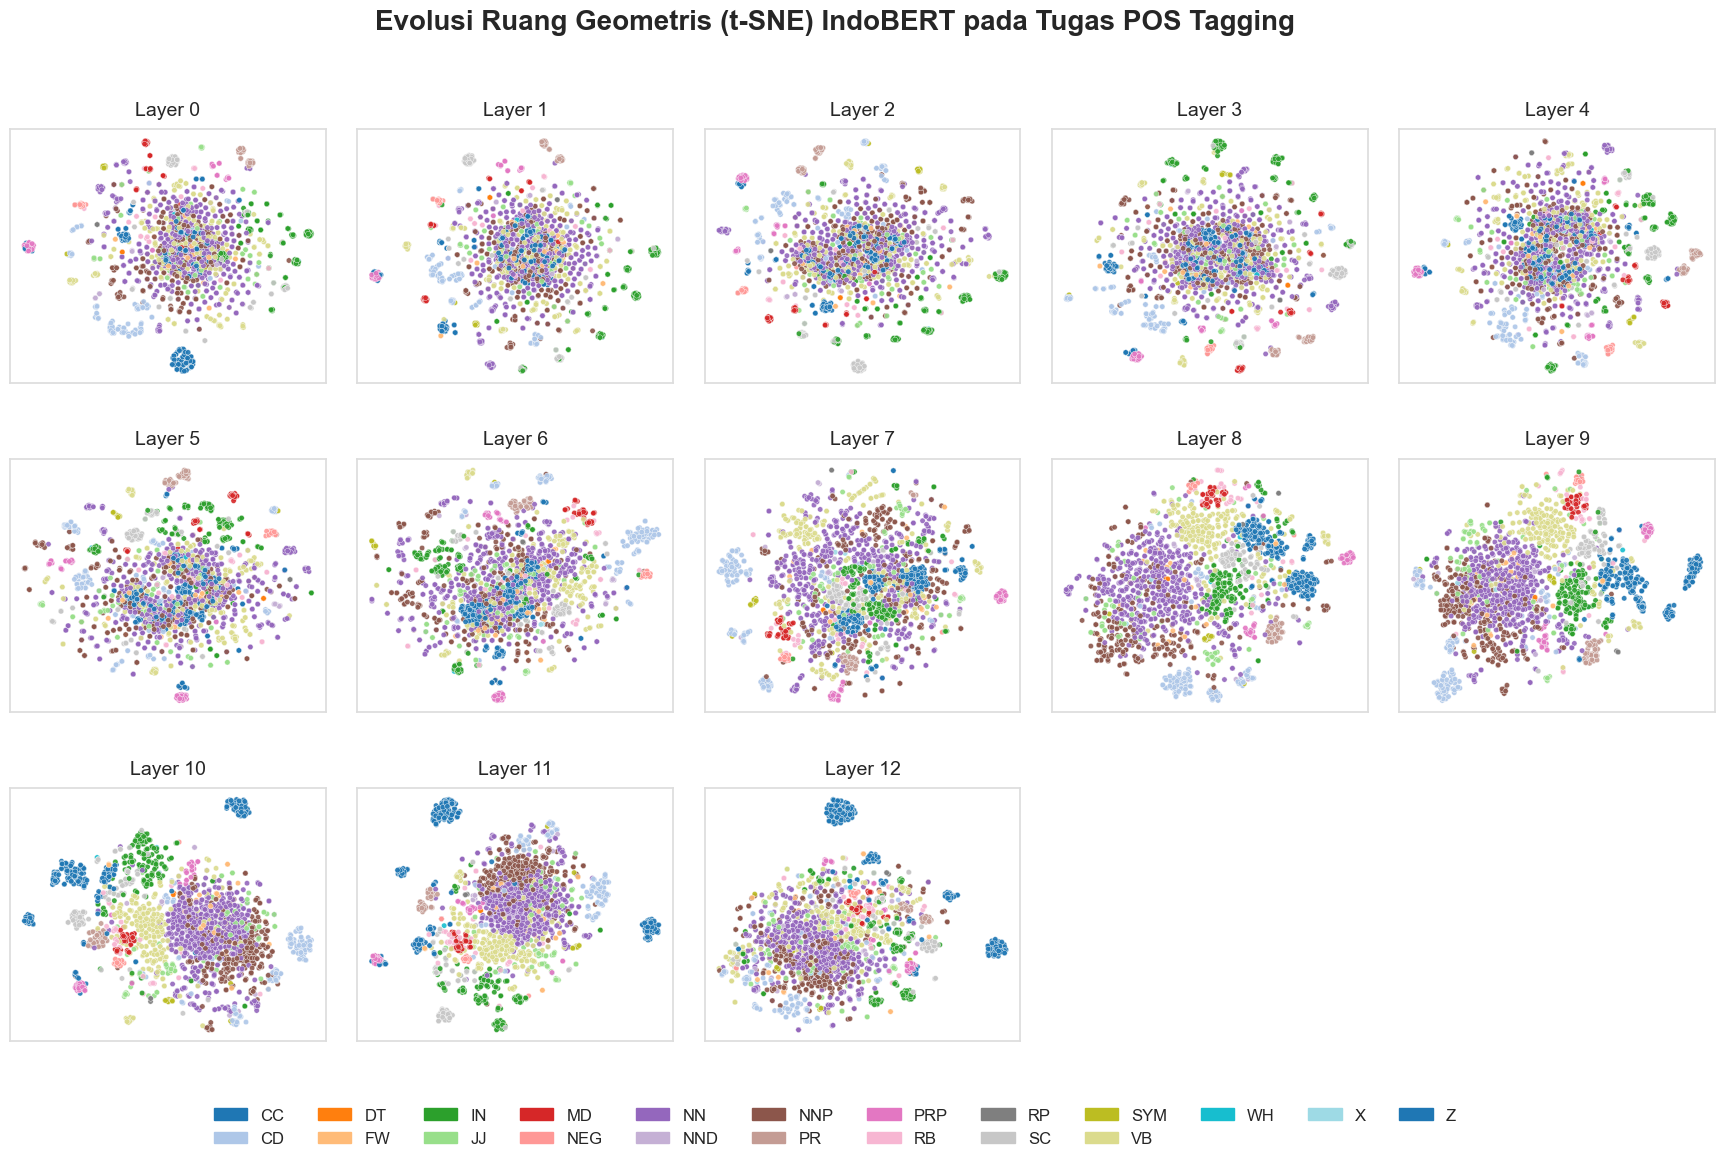

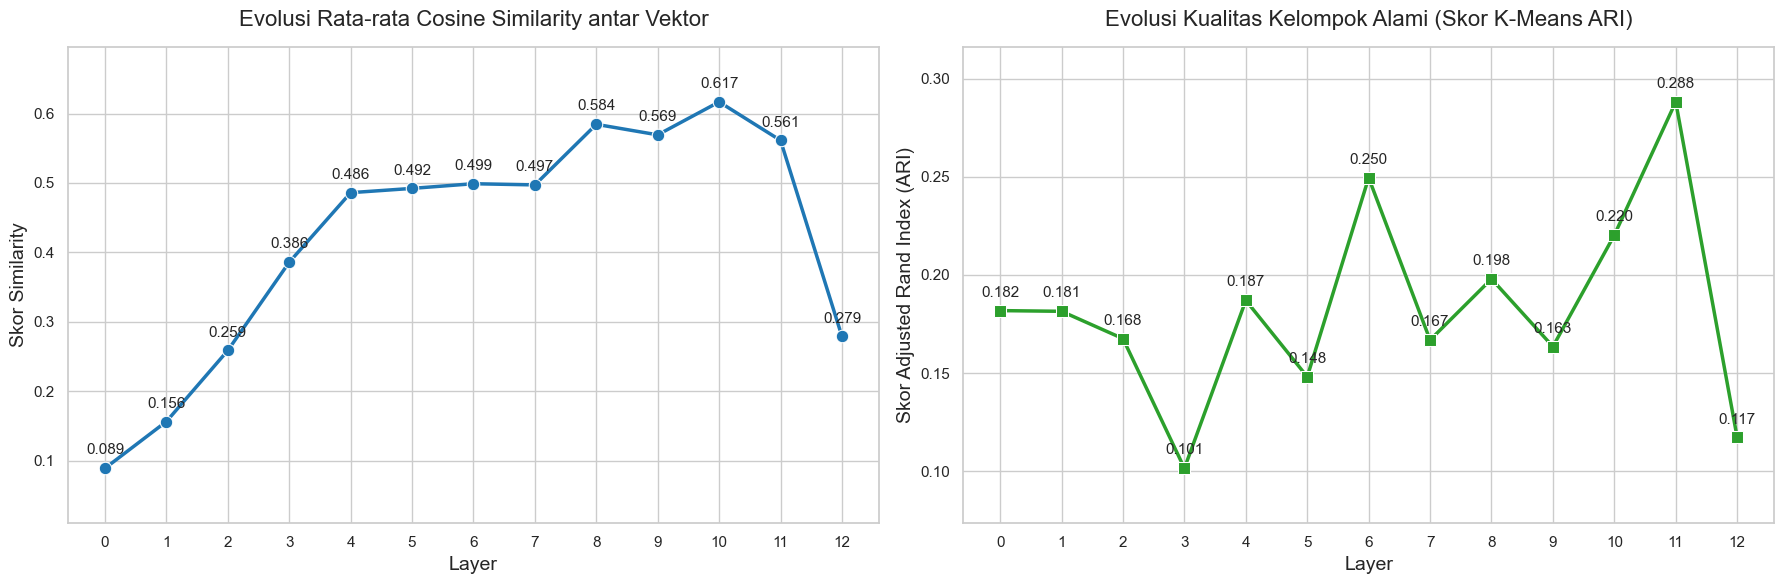


✅ STEP 12 Selesai! Visualisasi berhasil diperbaiki dan dipisah menjadi 2 gambar profesional.


In [35]:
# =========================================================
# STEP 12 (REVISI FINAL): VISUALISASI LENGKAP & RAPI 
# (t-SNE ALL LAYERS, COSINE LINEPLOT, K-MEANS LINEPLOT)
# =========================================================

print("Memulai Analisis Geometris Komprehensif (Memakan waktu 2-3 menit)...")

# 1. SAMPLING DATA (2000 Kata)
np.random.seed(42)
TOTAL_SAMPLES = 2000
sample_indices = np.random.choice(len(y_train_indo), size=TOTAL_SAMPLES, replace=False)

y_sample_num = y_train_indo[sample_indices]
y_sample_text = label_encoder.inverse_transform(y_sample_num)

# Siapkan memori untuk menyimpan hasil perhitungan
tsne_results = {}
ari_scores = []
cosine_scores = []

# 2. HITUNG METRIK UNTUK SELURUH 13 LAYER
# Kita gunakan tqdm agar Anda bisa melihat loading per-layer nya
for layer_idx in tqdm(range(13), desc="Memproses Metrik & t-SNE"):
    # Ambil matriks dari hard disk
    X_sample = X_train_indo_mmap[layer_idx][sample_indices]
    
    # A. t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_results[layer_idx] = tsne.fit_transform(X_sample)
    
    # B. K-Means
    kmeans = KMeans(n_clusters=NUM_CLASSES, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_sample)
    ari_scores.append(adjusted_rand_score(y_sample_num, cluster_labels))
    
    # C. Cosine Similarity
    avg_sim = np.mean(cosine_similarity(X_sample))
    cosine_scores.append(avg_sim)

# =========================================================
# 3. VISUALISASI 1 : PETA T-SNE 13 LAYER YANG SANGAT RAPI
# =========================================================
sns.set_theme(style="white") # Background putih bersih
fig_tsne, axes = plt.subplots(3, 5, figsize=(22, 12))
fig_tsne.suptitle('Evolusi Ruang Geometris (t-SNE) IndoBERT pada Tugas POS Tagging', fontsize=20, fontweight='bold')
axes = axes.flatten()

# Siapkan palet warna cerah (tab20) yang cukup untuk banyak POS Tag
unique_tags = np.unique(y_sample_text)
palette = sns.color_palette("tab20", n_colors=len(unique_tags))

# Plot scatter untuk tiap layer
for layer_idx in range(13):
    ax = axes[layer_idx]
    sns.scatterplot(
        x=tsne_results[layer_idx][:, 0], y=tsne_results[layer_idx][:, 1],
        hue=y_sample_text, hue_order=unique_tags, palette=palette,
        s=15, alpha=0.9, ax=ax, legend=False # Legenda per kotak dimatikan
    )
    ax.set_title(f"Layer {layer_idx}", fontsize=14, pad=10)
    ax.set_xticks([]) # Hilangkan koordinat angka
    ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_color('#dddddd') # Jadikan garis pinggir abu-abu tipis

# Matikan 2 kotak kosong agar tidak terlihat kotor
axes[13].axis('off')
axes[14].axis('off')

# Buat SATU Legenda Global, taruh berjejer di bagian paling bawah
legend_patches = [mpatches.Patch(color=palette[i], label=unique_tags[i]) for i in range(len(unique_tags))]
fig_tsne.legend(handles=legend_patches, loc='lower center', ncol=min(12, len(unique_tags)), 
                bbox_to_anchor=(0.5, 0.02), fontsize=12, frameon=False)

plt.subplots_adjust(bottom=0.12, hspace=0.3, wspace=0.1)
plt.savefig('indobert_tsne_all_layers.png', dpi=300)
plt.show()

# =========================================================
# 4. VISUALISASI 2 : GRAFIK COSINE & K-MEANS
# =========================================================
sns.set_theme(style="whitegrid")
fig_metrics, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot A: Cosine Similarity
sns.lineplot(x=range(13), y=cosine_scores, marker='o', color='#1f77b4', linewidth=2.5, markersize=9, ax=ax1)
ax1.set_title("Evolusi Rata-rata Cosine Similarity antar Vektor", fontsize=16, pad=15)
ax1.set_xlabel("Layer", fontsize=14)
ax1.set_ylabel("Skor Similarity", fontsize=14)
ax1.set_xticks(range(13))

# --- TAMBAHAN: Menempelkan angka eksak di Plot A (Cosine) ---
for x, y in zip(range(13), cosine_scores):
    # Mengambil 3 angka di belakang koma (contoh: 0.123)
    ax1.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=11)

# Plot B: K-Means ARI
sns.lineplot(x=range(13), y=ari_scores, marker='s', color='#2ca02c', linewidth=2.5, markersize=9, ax=ax2)
ax2.set_title("Evolusi Kualitas Kelompok Alami (Skor K-Means ARI)", fontsize=16, pad=15)
ax2.set_xlabel("Layer", fontsize=14)
ax2.set_ylabel("Skor Adjusted Rand Index (ARI)", fontsize=14)
ax2.set_xticks(range(13))

# --- TAMBAHAN: Menempelkan angka eksak di Plot B (K-Means) ---
for x, y in zip(range(13), ari_scores):
    # Mengambil 3 angka di belakang koma
    ax2.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=11)

# Menambahkan sedikit ruang kosong di 'atap' grafik agar angka tertinggi tidak menabrak garis batas atas
ax1.margins(y=0.15)
ax2.margins(y=0.15)

plt.tight_layout()
plt.savefig('indobert_metrics_cosine_kmeans.png', dpi=300)
plt.show()

print("\n✅ STEP 12 Selesai! Visualisasi berhasil diperbaiki dan dipisah menjadi 2 gambar profesional.")